# Figure 6 (Drift) — cell-cycle-regressed pipeline

**What this notebook does.** Loads the same multiome inputs as
`Figure6_multiome_FA_integration_drift.ipynb`, but **regresses S/G2M cell-cycle
scores out of the joint FA latent before refitting Palantir + scJDO**. The
original notebook performs no cell-cycle correction; this one does, and reports
both pipelines side-by-side so the difference is auditable.

**Why this matters.** The original pipeline's dominant instability signal
in the dorsal lineage tracks proliferation (S/G2M phases). Without
correction, the "neurogenic" archetype claim cannot be cleanly separated
from cell-cycle progression. After correction we ask:

1. Does the **trajectory** survive — do canonical markers retain their
   pseudotime ordering (Pax6/Sox2 early → Eomes/Tbr2 mid → Neurog2 / Neurod1/2 / Tbr1 late)?
   If they don't, we've over-corrected and the cleaned result is itself an
   artifact.
2. After correction, does an archetype peak at an **interior** pseudotime
   (the radial-glia → IPC or IPC → neuron transition), driven by
   neurogenic genes, with neurogenic regulators surfacing in the
   unfiltered list?
3. If correction simply removes the signal, the honest reading is that
   this branch's recoverable dynamics were dominated by cell-cycle.


In [1]:

import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import palantir
import scjdo as sjd

mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.family':  'DejaVu Sans',
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

FIG6_DIR        = 'results/figure6_multiome_fa/'
REP             = 'X_fa_joint'
REP_CC          = 'X_fa_joint_cc'        # CC-regressed latent
N_DM_COMPONENTS = 20
N_WAYPOINTS     = 500
N_ARCHETYPES    = 5
N_EPOCHS        = 5000
BIAS_STRENGTH   = 1.5
ORGANISM        = 'mouse'
SEED            = 42

OUTDIR = 'results/figure6_multiome_fa_drift_cc/'
os.makedirs(OUTDIR, exist_ok=True)

print(f'scjdo v{sjd.__version__}  ·  palantir v{palantir.__version__}  ·  scanpy v{sc.__version__}')


scjdo v0.3.0  ·  palantir v1.4.4  ·  scanpy v1.11.5


## Step 1 — Load the joint FA AnnData (same input as the uncorrected notebook)

In [2]:

rna_path  = FIG6_DIR + 'adata_multiome_fa.h5ad'
atac_path = FIG6_DIR + 'adata_multiome_fa_atac.h5ad'

for p in [rna_path, atac_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Missing {p} — run Figure6_multiome_FA_integration.ipynb first.')

ad      = sc.read_h5ad(rna_path)
ad_atac = sc.read_h5ad(atac_path)
assert REP in ad.obsm, f'{REP} missing from input h5ad'
if not ad_atac.obs_names.equals(ad.obs_names):
    ad_atac = ad_atac[ad.obs_names].copy()

# Detect whether uncorrected scJDO results live in this h5ad — used for
# side-by-side comparison at the end. Doesn't gate execution.
_uncorrected_keys = sorted(k for k in ad.uns.keys()
                           if k.startswith('scjdo_') and not k.startswith('scjdo_cc_')
                           and isinstance(ad.uns[k], dict)
                           and 'J_tensor' in ad.uns[k])
has_uncorrected = len(_uncorrected_keys) > 0
print(f'RNA  : {ad.n_obs} cells × {ad.n_vars} genes')
print(f'ATAC : {ad_atac.n_obs} cells × {ad_atac.n_vars} peaks')
print(f'Uncorrected reference results present: {has_uncorrected}  ({_uncorrected_keys})')


RNA  : 4878 cells × 18354 genes
ATAC : 4878 cells × 171106 peaks
Uncorrected reference results present: False  ([])


## Step 2 — Cell-cycle scoring (mouse markers)

Tirosh S/G2M gene lists, translated to mouse symbols. We score the **raw,
log-normalised** RNA so we can later regress the resulting S_score / G2M_score
out of the joint latent. (We do not modify the raw expression matrix; the
correction applies only to the latent that scJDO sees.)


In [3]:

# Tirosh et al. 2016 cell-cycle markers, mouse symbols
S_GENES = [
    'Mcm5','Pcna','Tyms','Fen1','Mcm2','Mcm4','Rrm1','Ung','Gins2','Mcm6',
    'Cdca7','Dtl','Prim1','Uhrf1','Mlf1ip','Hells','Rfc2','Rpa2','Nasp',
    'Rad51ap1','Gmnn','Wdr76','Slbp','Ccne2','Ubr7','Pold3','Msh2','Atad2',
    'Rad51','Rrm2','Cdc45','Cdc6','Exo1','Tipin','Dscc1','Blm','Casp8ap2',
    'Usp1','Clspn','Pola1','Chaf1b','Brip1','E2f8',
]
G2M_GENES = [
    'Hmgb2','Cdk1','Nusap1','Ube2c','Birc5','Tpx2','Top2a','Ndc80','Cks2',
    'Nuf2','Cks1b','Mki67','Tmpo','Cenpf','Tacc3','Fam64a','Smc4','Ccnb2',
    'Ckap2l','Ckap2','Aurkb','Bub1','Kif11','Anp32e','Tubb4b','Gtse1',
    'Kif20b','Hjurp','Cdca3','Hn1','Cdc20','Ttk','Cdc25c','Kif2c','Rangap1',
    'Ncapd2','Dlgap5','Cdca2','Cdca8','Ect2','Kif23','Hmmr','Aurka','Psrc1',
    'Anln','Lbr','Ckap5','Cenpe','Ctcf','Nek2','G2e3','Gas2l3','Cbx5','Cenpa',
]
S_GENES   = [g for g in S_GENES   if g in ad.var_names]
G2M_GENES = [g for g in G2M_GENES if g in ad.var_names]
print(f'S genes available  : {len(S_GENES)}  ({S_GENES[:8]} …)')
print(f'G2M genes available: {len(G2M_GENES)}  ({G2M_GENES[:8]} …)')

# We need log-normalised RNA in X for score_genes; the multiome h5ad may
# already have it there. If raw counts only, log-normalise into a copy.
ad_score = ad.copy()
if ad_score.X.max() > 50:   # heuristic: looks like raw counts
    sc.pp.normalize_total(ad_score, target_sum=1e4)
    sc.pp.log1p(ad_score)
    print('Computed log1p(normalised) for cell-cycle scoring.')

sc.tl.score_genes_cell_cycle(ad_score, s_genes=S_GENES, g2m_genes=G2M_GENES)

# Copy scores back to the working object
for col in ['S_score', 'G2M_score', 'phase']:
    ad.obs[col] = ad_score.obs[col].values
del ad_score

print('\nPhase composition:')
print(ad.obs['phase'].value_counts().to_string())
print(f'S_score   range [{ad.obs.S_score.min():+.3f}, {ad.obs.S_score.max():+.3f}]')
print(f'G2M_score range [{ad.obs.G2M_score.min():+.3f}, {ad.obs.G2M_score.max():+.3f}]')


S genes available  : 42  (['Mcm5', 'Pcna', 'Tyms', 'Fen1', 'Mcm2', 'Mcm4', 'Rrm1', 'Ung'] …)
G2M genes available: 52  (['Hmgb2', 'Cdk1', 'Nusap1', 'Ube2c', 'Birc5', 'Tpx2', 'Top2a', 'Ndc80'] …)

Phase composition:
phase
G1     3691
S       623
G2M     564
S_score   range [-0.207, +0.950]
G2M_score range [-0.211, +1.627]


## Step 3 — Residualise the joint latent against S/G2M

We regress S_score and G2M_score (with intercept) out of every column of
`X_fa_joint`, taking the residuals as the new latent. This removes the
linear contribution of cell-cycle phase to the embedding before Palantir
or scJDO see it.


In [4]:

def residualise(X, covariates):
    # Per-column linear residualisation; covariates is a (N, K) array.
    X = np.asarray(X, dtype=np.float32)
    Z = np.column_stack([np.ones(len(X)), covariates]).astype(np.float32)
    # Per-column OLS; equivalent to (I - Z(ZᵀZ)⁻¹Zᵀ) X
    beta = np.linalg.lstsq(Z, X, rcond=None)[0]
    return (X - Z @ beta).astype(np.float32)

S   = ad.obs['S_score'  ].values.astype(np.float32)
G2M = ad.obs['G2M_score'].values.astype(np.float32)
covar = np.column_stack([S, G2M])

X = ad.obsm[REP].astype(np.float32)
X_cc = residualise(X, covar)
ad.obsm[REP_CC] = X_cc

# How much of the joint latent variance did CC explain?
var_before = X.var(0).sum()
var_after  = X_cc.var(0).sum()
frac_removed = 1.0 - var_after / var_before
print(f'Joint latent variance: before = {var_before:.3f}  after = {var_after:.3f}')
print(f'Fraction removed by S/G2M regression: {frac_removed*100:.1f}%')

# Per-component reduction
comp_reduction = 1.0 - X_cc.var(0) / np.clip(X.var(0), 1e-12, None)
print('\nPer-component variance fraction removed (top 10):')
order = np.argsort(-comp_reduction)
for k in order[:10]:
    print(f'  F{k+1:2d}: {comp_reduction[k]*100:5.1f}%')


Joint latent variance: before = 28.577  after = 27.135
Fraction removed by S/G2M regression: 5.0%

Per-component variance fraction removed (top 10):
  F 8:  35.8%
  F 2:  28.5%
  F25:  26.8%
  F23:  16.9%
  F 7:  15.3%
  F 3:  12.6%
  F 9:   1.9%
  F15:   1.6%
  F 4:   1.1%
  F19:   1.1%


## Step 4 — Re-run Palantir on the CC-regressed latent

Diffusion maps, multiscale space, neighbours, UMAP, MAGIC imputation, and
finally `palantir.core.run_palantir`. We **reuse the same START_CELL and
TERMINAL_STATES** as the uncorrected notebook if they exist in the h5ad,
otherwise pick a defensible default (top-Sox2 cell = start; top-Tbr1 cell
in the highest-pseudotime cluster = terminus).

In [5]:

# Try to reuse start / terminal from the original Palantir result if it
# was persisted on the input h5ad
START_CELL     = ad.uns.get('palantir_start_cell',     None)
TERMINAL_STATES = ad.uns.get('palantir_terminal_states', None)

if START_CELL is None:
    # Heuristic: highest Sox2+Pax6 expression in the original-latent-derived UMAP
    s = pd.Series(
        np.asarray((ad[:, [g for g in ['Sox2','Pax6'] if g in ad.var_names]].X).mean(axis=1)).ravel(),
        index=ad.obs_names,
    )
    START_CELL = s.idxmax()
    print(f'[heuristic] START_CELL = {START_CELL}  (max Sox2+Pax6)')

if TERMINAL_STATES is None:
    tb = [g for g in ['Tbr1','Neurod2'] if g in ad.var_names]
    s = pd.Series(np.asarray(ad[:, tb].X.mean(axis=1)).ravel(), index=ad.obs_names)
    TERMINAL_STATES = pd.Series({s.idxmax(): 'ExcNeuron'})
    print(f'[heuristic] TERMINAL = {list(TERMINAL_STATES.index)}')

_ = palantir.utils.run_diffusion_maps(ad, n_components=N_DM_COMPONENTS, pca_key=REP_CC)
_ = palantir.utils.determine_multiscale_space(ad)
sc.pp.neighbors(ad, use_rep=REP_CC, n_neighbors=15, key_added='cc_nbr')
sc.tl.umap(ad, neighbors_key='cc_nbr', random_state=SEED)
ad.obsm['X_umap_cc'] = ad.obsm['X_umap']

try:
    palantir.utils.run_magic_imputation(ad)
except Exception as e:
    print(f'[warn] MAGIC skipped: {type(e).__name__}: {e}')

pr_res = palantir.core.run_palantir(
    ad, START_CELL,
    num_waypoints   = N_WAYPOINTS,
    terminal_states = TERMINAL_STATES,
)
# Save CC-pseudotime to a dedicated column so we don't clobber the original
ad.obs['palantir_pseudotime_cc'] = ad.obs['palantir_pseudotime'].copy()
ad.obsm['palantir_fate_probabilities_cc'] = ad.obsm['palantir_fate_probabilities'].copy()
print(f'\nCC-regressed pseudotime range '
      f'[{ad.obs.palantir_pseudotime_cc.min():.3f}, '
      f'{ad.obs.palantir_pseudotime_cc.max():.3f}]')

# Branch masks
palantir.presults.select_branch_cells(ad, q=0.01, eps=0.01,
    masks_key='branch_masks_cc', save_as_df=True)
print('Branch cell counts (CC-regressed):')
for col in ad.obsm['branch_masks_cc'].columns:
    n = int(ad.obsm['branch_masks_cc'][col].sum())
    print(f'  {col}: {n} ({100*n/ad.n_obs:.0f}%)')

# Cell-fate label for the bias prior
fate_probs = ad.obsm['palantir_fate_probabilities_cc']
ad.obs['cell_fate_cc'] = fate_probs.idxmax(axis=1).astype(str)
entropy_thr = ad.obs['palantir_entropy'].quantile(0.75)
ad.obs.loc[ad.obs['palantir_entropy'] >= entropy_thr, 'cell_fate_cc'] = 'Progenitor'


[heuristic] START_CELL = TGAGTTTCAGCCAGTT-1  (max Sox2+Pax6)
[heuristic] TERMINAL = ['AATGTCCAGATAAAGC-1']
Sampling and flocking waypoints...
Time for determining waypoints: 8.424917856852214e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.019823928674062092 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9993
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...

CC-regressed pseudotime range [0.000, 1.000]
Branch cell counts (CC-regressed):
  ExcNeuron: 4835 (99%)


## Step 5 — Critical check: marker ordering survives the correction

We confirm canonical dorsal-cortex markers retain their pseudotime order
under both the uncorrected and CC-regressed pseudotimes. If correction
breaks the ordering (e.g. neurons end up "earlier" than progenitors),
we have over-corrected and any cleaned downstream result is itself an
artifact.

Markers present: ['Pax6', 'Sox2', 'Hes1', 'Eomes', 'Neurog2', 'Neurod1', 'Neurod2', 'Tbr1']

Marker centre-of-mass pseudotime (lower = earlier):
   gene       role  mean_pt_uncorrected  mean_pt_cc
   Hes1 progenitor                0.280       0.280
   Pax6 progenitor                0.390       0.390
  Eomes        IPC                0.468       0.468
Neurog2        IPC                0.489       0.489
   Sox2 progenitor                0.548       0.548
Neurod1     neuron                0.559       0.559
Neurod2     neuron                0.578       0.578
   Tbr1     neuron                0.607       0.607


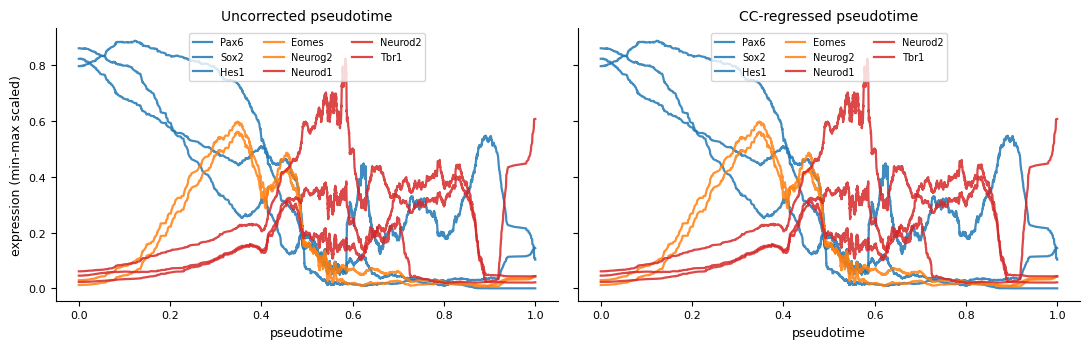

In [6]:

MARKERS = {
    'Pax6'   : 'progenitor',
    'Sox2'   : 'progenitor',
    'Hes1'   : 'progenitor',
    'Eomes'  : 'IPC',
    'Tbr2'   : 'IPC',        # synonym for Eomes — keep both if present
    'Neurog2': 'IPC',
    'Neurod1': 'neuron',
    'Neurod2': 'neuron',
    'Tbr1'   : 'neuron',
}
present = [g for g in MARKERS if g in ad.var_names]
print(f'Markers present: {present}')

def magic_layer():
    return 'MAGIC_imputed_data' if 'MAGIC_imputed_data' in ad.layers else None

def expr(gene):
    j = ad.var_names.get_loc(gene)
    if magic_layer():
        X = ad.layers[magic_layer()][:, j]
    else:
        X = ad.X[:, j]
    return np.asarray(X.toarray() if sp.issparse(X) else X).ravel()

def mean_pt_weighted_by_expr(pt, e):
    # Centre-of-mass pseudotime, weighted by gene expression.
    w = np.clip(e, 0, None)
    return float(np.average(pt, weights=w)) if w.sum() > 0 else float('nan')

pt_orig = ad.obs.palantir_pseudotime.values if 'palantir_pseudotime' in ad.obs else None
pt_cc   = ad.obs.palantir_pseudotime_cc.values

rows = []
for gene in present:
    e = expr(gene)
    rows.append({
        'gene':  gene,
        'role':  MARKERS[gene],
        'mean_pt_uncorrected': mean_pt_weighted_by_expr(pt_orig, e) if pt_orig is not None else np.nan,
        'mean_pt_cc':          mean_pt_weighted_by_expr(pt_cc,   e),
    })
df_markers = pd.DataFrame(rows).sort_values('mean_pt_cc').reset_index(drop=True)
print('\nMarker centre-of-mass pseudotime (lower = earlier):')
print(df_markers.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

# Visual check: pseudotime curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, pt, title in [(axes[0], pt_orig, 'Uncorrected pseudotime'),
                      (axes[1], pt_cc,   'CC-regressed pseudotime')]:
    if pt is None:
        ax.text(0.5, 0.5, 'no uncorrected pseudotime in input h5ad',
                ha='center', va='center'); ax.set_axis_off(); continue
    order = np.argsort(pt)
    for gene, role in MARKERS.items():
        if gene not in present: continue
        e = expr(gene)
        e = (e - e.min()) / max(e.max() - e.min(), 1e-9)
        # Light smoothing along pseudotime
        from scipy.ndimage import uniform_filter1d
        e_smooth = uniform_filter1d(e[order], size=max(50, len(e)//40))
        c = {'progenitor':'C0','IPC':'C1','neuron':'C3'}[role]
        ax.plot(pt[order], e_smooth, color=c, lw=1.6, alpha=0.85, label=gene)
    ax.set_xlabel('pseudotime'); ax.set_title(title)
    ax.legend(fontsize=7, ncol=3, loc='upper center')
axes[0].set_ylabel('expression (min-max scaled)')
plt.tight_layout()
plt.savefig(OUTDIR + 'marker_ordering_pre_vs_post_cc.pdf')
plt.show()


## Step 6 — Fit scJDO drift on the CC-regressed latent

Same `fit_drift_branches` configuration as the uncorrected notebook —
**kernel windowing is the default** (no legacy `n_windows` / overlap kwargs).
Results are stored under `scjdo_cc_<branch>` so they live alongside any
uncorrected `scjdo_<branch>` entries.

In [7]:

BRANCH_NAMES = list(ad.obsm['branch_masks_cc'].columns)
print(f'CC branches: {BRANCH_NAMES}')

branch_models_cc = sjd.tl.fit_drift_branches(
    ad,
    rep                = REP_CC,
    branch_key         = 'branch_masks_cc',
    branch_names       = BRANCH_NAMES,
    time_key           = 'palantir_pseudotime_cc',
    groupby            = 'cell_fate_cc',
    progenitor_cluster = 'Progenitor',
    terminal_clusters  = {b: b for b in BRANCH_NAMES},
    bias_strength      = BIAS_STRENGTH,
    n_archetypes       = N_ARCHETYPES,
    n_epochs           = N_EPOCHS,
    vel_scale          = 2.0,
    n_eff_min          = 50.0,
    seed               = SEED,
    key_prefix         = 'scjdo_cc',
)

print('\nscJDO branch results (CC-regressed):')
for name in branch_models_cc:
    key = f'scjdo_cc_{name}'
    res    = ad.uns[key]
    eig    = res['max_real_eig']
    peak_t = res['t_centers'][np.argmax(eig)]
    n_sens = int((eig > 0.05).sum())
    print(f'  {name:12s}: R²={res["r2"]:.3f}, n={res["n_cells"]}, '
          f'peak_t={peak_t:.3f}, max_eig={eig.max():.4f}, '
          f'n_sensitive={n_sens}/{len(eig)}, '
          f"h*={res.get('bandwidth', 'n/a')}")


CC branches: ['ExcNeuron']
[bias] Progenitor 'Progenitor': 4878 cells, centroid computed in X_fa_joint_cc

Branch: ExcNeuron  (4835 cells)
Computing pseudotime-gradient velocity prior...
DriftField: 879,292 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 77.2597
Computing per-cell Jacobians...


Per-cell Jacobians:   0%|          | 0/38 [00:00<?, ?it/s]

Kernel-weighted temporal operator: grid_size=200, bandwidth='auto', adaptive=False
[kernel-windowing] selecting bandwidth from [0.01, 0.02, 0.03, 0.05, 0.08, 0.1]  (n_boot=20, n_eff_min=50.0)
  h=0.010  R=0.959  C=0.262  L=2.581  S=0.6482  n_eff_min(interior)=17.2
  h=0.020  R=0.984  C=0.252  L=2.251  S=0.5589  n_eff_min(interior)=39.8
  h=0.030  R=0.991  C=0.232  L=1.866  S=0.4290  n_eff_min(interior)=65.6
  h=0.050  R=0.996  C=0.222  L=1.326  S=0.2934  n_eff_min(interior)=137.0
  h=0.080  R=0.998  C=0.195  L=1.099  S=0.2135  n_eff_min(interior)=262.2
  h=0.100  R=0.998  C=0.186  L=1.125  S=0.2090  n_eff_min(interior)=293.0
[kernel-windowing] selected h*=0.0300  R=0.991  C=0.232  L=1.866  S=0.4290
Running archetype decomposition (semi-NMF)...
Done. R²=0.997 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.997  stored in adata.uns['scjdo_cc_ExcNeuron']

Branch results stored: ['scjdo_cc_ExcNeuron']

scJDO branch results (CC-regressed):
  ExcNeuron   : R²=0.997, n=4835, pea

## Step 7 — Instability genes + regulators (no allowlist)

Same call signature as the uncorrected pipeline. We deliberately do
**not** filter the regulator list to neurogenic candidates — if
neurogenic TFs (Neurog2, Eomes, Neurod1/2, Tbr1 …) surface naturally
after correction that is a real finding; if they don't, that's also a
real finding.

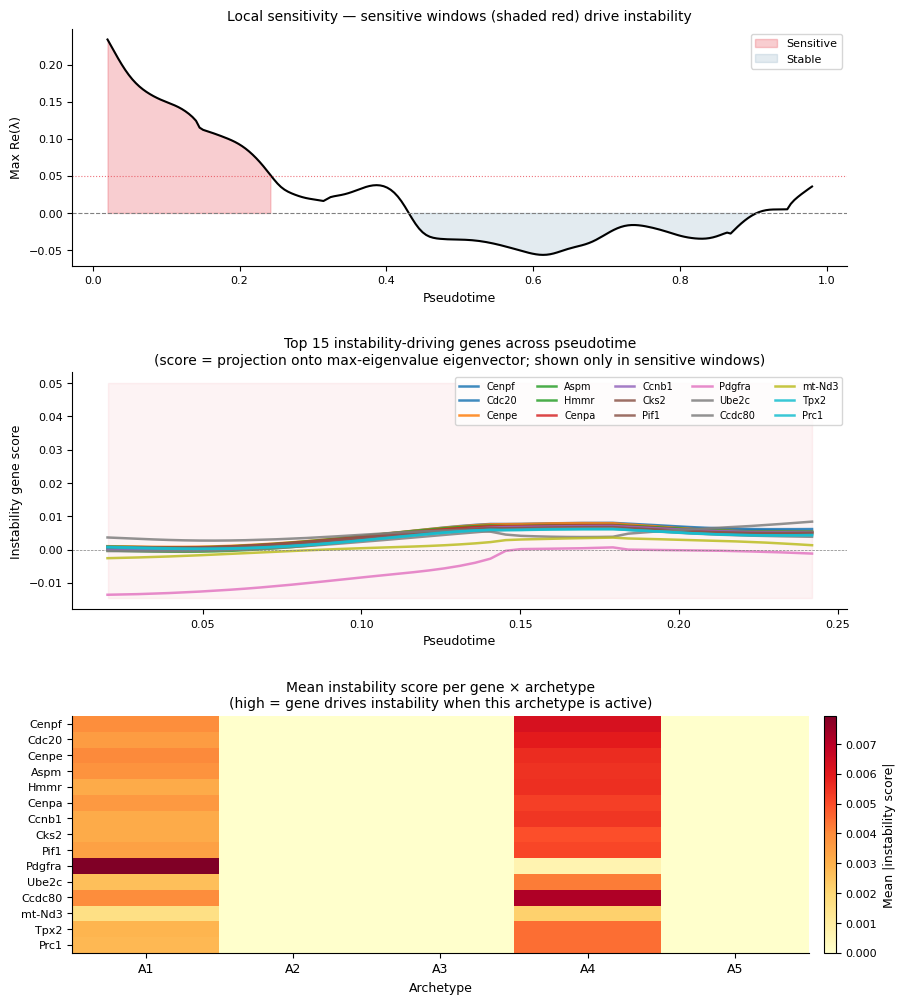

 rank   gene  mean_instability_score  peak_pseudotime primary_archetype
    1  Cenpf                  0.0042            0.179                A1
    2  Cdc20                  0.0042            0.179                A1
    3  Cenpe                  0.0040            0.170                A1
    4   Aspm                  0.0039            0.174                A1
    5   Hmmr                  0.0038            0.179                A1
    6  Cenpa                  0.0038            0.174                A1
    7  Ccnb1                  0.0037            0.179                A1
    8   Cks2                  0.0036            0.179                A1
    9   Pif1                  0.0034            0.174                A1
   10 Pdgfra                  0.0034            0.020                A1
   11  Ube2c                  0.0034            0.174                A1
   12 Ccdc80                  0.0033            0.242                A4
   13 mt-Nd3                  0.0033            0.179           

In [8]:

df_genes_cc = {}
df_regs_cc  = {}
_EMPTY_REGS = pd.DataFrame(columns=[
    'regulator','weighted_score','mean_instability','enrichment_score',
    'branch_specificity','peak_archetype','db_confidence','n_targets',
    'enrichment_pval','top_targets',
])

for name in BRANCH_NAMES:
    key      = f'scjdo_cc_{name}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    ad_b     = ad[cell_idx].copy()
    ad_b.uns[key] = ad.uns[key]

    table = sjd.pl.instability_genes(
        ad_b, key=key, n_genes=15,
        save=OUTDIR + f'instab_cc_{name}.pdf',
    )
    df_genes_cc[name] = table
    table.to_csv(OUTDIR + f'instability_genes_cc_{name}.csv', index=False)

    reg_key = f'scjdo_cc_regulators_{name}'
    try:
        df_reg = sjd.tl.infer_regulators(
            ad_b, key=key, organism=ORGANISM, min_targets=1,
            n_top=15, key_added=reg_key, verbose=False,
        )
        if reg_key in ad_b.uns:
            ad.uns[reg_key] = ad_b.uns[reg_key]
    except Exception as e:
        print(f'  [{name}] infer_regulators failed ({type(e).__name__}: {e}) — empty fallback')
        df_reg = _EMPTY_REGS.copy()
    df_regs_cc[name] = df_reg
    df_reg.to_csv(OUTDIR + f'regulators_cc_{name}.csv', index=False)

    top_genes = (table['gene'].head(10).tolist()
                 if 'gene' in getattr(table, 'columns', []) and len(table) else [])
    top_regs  = (df_reg['regulator'].head(10).tolist()
                 if 'regulator' in getattr(df_reg, 'columns', []) and len(df_reg) else ['(none)'])
    print(f'\n{name} (CC-regressed):')
    print(f'  Top instab genes : {top_genes}')
    print(f'  Top regulators   : {top_regs}')


## Step 8 — Looking for the neurogenic archetype

For each CC branch, scan the K archetypes for one whose activation peaks
at an **interior** pseudotime (0.25 ≤ τ ≤ 0.75) AND whose top gene loadings
include canonical neurogenic markers. A hit is the "rescued" archetype the
methodology was designed to find.

In [9]:

NEUROGENIC_GENES = {'Neurog2','Neurog1','Eomes','Tbr2','Neurod1','Neurod2',
                    'Tbr1','Satb2','Bcl11b','Insm1','Sox4','Sox11'}

def interior_archetype(name, lo=0.25, hi=0.75, top_n=50):
    res = ad.uns[f'scjdo_cc_{name}']
    acts  = res['activations']                         # (T, K)
    t_c   = res['t_centers']
    K     = acts.shape[1]
    gene_names = res.get('gene_names') or list(ad.var_names)
    out = []
    for k in range(K):
        peak_t = float(t_c[np.argmax(acts[:, k])])
        is_interior = lo <= peak_t <= hi
        # Top genes for this archetype
        scores = res.get('gene_scores', {}).get(str(k))
        if scores is None:
            top_overlap = set()
        else:
            order = np.argsort(-np.abs(scores))[:top_n]
            top_set = {gene_names[j] for j in order}
            top_overlap = top_set & NEUROGENIC_GENES
        out.append({
            'archetype':       f'A{k+1}',
            'peak_t':          peak_t,
            'interior':        is_interior,
            'neurogenic_hits': sorted(top_overlap),
            'n_hits':          len(top_overlap),
        })
    return pd.DataFrame(out)

for name in BRANCH_NAMES:
    print(f'\n=== {name} ===')
    df = interior_archetype(name)
    print(df.to_string(index=False))
    flagged = df[df.interior & (df.n_hits > 0)]
    if len(flagged):
        print(f'  ► interior + neurogenic archetypes: {flagged["archetype"].tolist()}')
    else:
        print('  ► no archetype peaks at interior pseudotime with neurogenic genes')



=== ExcNeuron ===
archetype   peak_t  interior neurogenic_hits  n_hits
       A1 0.020000     False              []       0
       A2 0.980000     False              []       0
       A3 0.782211     False              []       0
       A4 0.314271      True              []       0
       A5 0.565126      True         [Satb2]       1
  ► interior + neurogenic archetypes: ['A5']


## Step 9 — Side-by-side: uncorrected vs CC-regressed sensitivity

2026-06-01 08:10:50 | [INFO] maxp pruned
2026-06-01 08:10:50 | [INFO] cmap pruned
2026-06-01 08:10:50 | [INFO] kern dropped
2026-06-01 08:10:50 | [INFO] post pruned
2026-06-01 08:10:50 | [INFO] FFTM dropped
2026-06-01 08:10:50 | [INFO] GPOS pruned
2026-06-01 08:10:50 | [INFO] GSUB pruned
2026-06-01 08:10:50 | [INFO] glyf pruned
2026-06-01 08:10:50 | [INFO] Added gid0 to subset
2026-06-01 08:10:50 | [INFO] Added first four glyphs to subset
2026-06-01 08:10:50 | [INFO] Closing glyph list over 'GSUB': 5 glyphs before
2026-06-01 08:10:50 | [INFO] Glyph names: ['.notdef', '.null', 'lambda', 'nonmarkingreturn', 'space']
2026-06-01 08:10:50 | [INFO] Glyph IDs:   [0, 1, 2, 3, 847]
2026-06-01 08:10:50 | [INFO] Closed glyph list over 'GSUB': 5 glyphs after
2026-06-01 08:10:50 | [INFO] Glyph names: ['.notdef', '.null', 'lambda', 'nonmarkingreturn', 'space']
2026-06-01 08:10:50 | [INFO] Glyph IDs:   [0, 1, 2, 3, 847]
2026-06-01 08:10:50 | [INFO] Closing glyph list over 'glyf': 5 glyphs before
2026

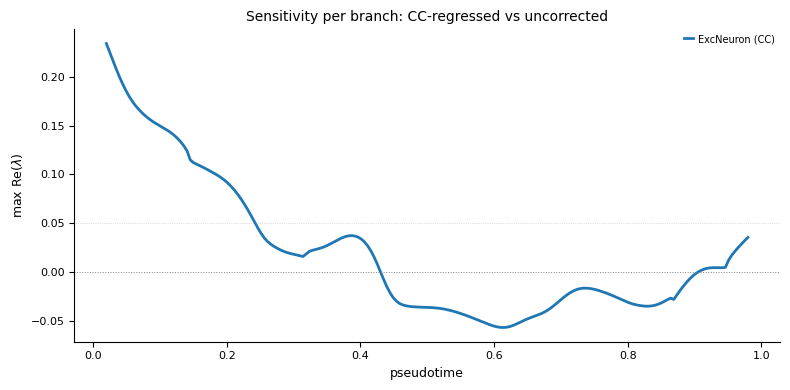

In [10]:

# Overlay max-Re(λ) curves under both pipelines (if uncorrected results exist)
fig, ax = plt.subplots(figsize=(8, 4))
for name in BRANCH_NAMES:
    res_cc = ad.uns[f'scjdo_cc_{name}']
    ax.plot(res_cc['t_centers'], res_cc['max_real_eig'], lw=2.0, label=f'{name} (CC)')
if has_uncorrected:
    for key in _uncorrected_keys:
        name = key.replace('scjdo_', '')
        if name in BRANCH_NAMES or name in ad.uns.get('palantir_branch_names', []):
            res = ad.uns[key]
            ax.plot(res['t_centers'], res['max_real_eig'], lw=1.4, ls='--',
                    alpha=0.85, label=f'{name} (uncorrected)')
ax.axhline(0, color='gray', lw=0.7, ls=':')
ax.axhline(0.05, color='gray', lw=0.5, ls=':', alpha=0.5)
ax.set_xlabel('pseudotime'); ax.set_ylabel(r'max Re($\lambda$)')
ax.legend(fontsize=7, ncol=2, loc='best')
ax.set_title('Sensitivity per branch: CC-regressed vs uncorrected')
plt.tight_layout(); plt.savefig(OUTDIR + 'sensitivity_cc_vs_uncorrected.pdf'); plt.show()


## Step 10 — Save the augmented AnnData

Writes a copy with both `scjdo_<branch>` (if the input had them) and
`scjdo_cc_<branch>` results, so the comparison can be regenerated without
re-training.

In [25]:
ad_save = ad.copy()
ad_save.uns = {}
ad_save.write_h5ad(out_h5ad)
print(f"Saved: {out_h5ad}")

Saved: results/figure6_multiome_fa_drift_cc/adata_multiome_drift_cc.h5ad


## How to read the result

1. **Marker ordering** (Step 5) — both panels must show Pax6/Sox2 early,
   Eomes/Tbr2 in the middle, Neurog2/Neurod1/2/Tbr1 late. If the CC panel
   collapses or reorders, the correction has destroyed the trajectory and
   downstream results are not trustworthy.
2. **Interior neurogenic archetype** (Step 8) — a row with `interior=True`
   and a non-empty `neurogenic_hits` is the result that rescues the
   neurogenic claim. Absence of such a row, after a valid trajectory in
   Step 5, is itself a defensible finding: this branch's recoverable
   dynamics under the FA + scJDO setup were dominated by proliferation.
3. **Sensitivity overlay** (Step 9) — solid (CC) vs dashed (uncorrected)
   curves quantify how much of the max-Re(λ) signal was cell-cycle.
